In [6]:
from qiskit import __version__
print(__version__)

2.4.1


# Importing Packages

In [7]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector, state_fidelity, Pauli, DensityMatrix, partial_trace
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit_aer.library import SaveDensityMatrix, SaveStatevector, SetDensityMatrix
from qiskit import transpile 
import numpy as np
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError
from qiskit.circuit.library import HGate, UnitaryGate, IGate
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, NullFormatter
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
from scipy.optimize import curve_fit

# Graphing Settings

In [8]:
mpl.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.size': 8,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'lines.linewidth': 1.2,
    'figure.dpi': 150,
})

# Importing Data

In [4]:
data1 = np.load("scaling.npz")
data2 = np.load("threshold.npz")

rounds_arr = data1["rounds_arr"]
output_error_rate_arr = data1["output_error_rate_arr"]
lambda_ = data1["lambda_"]
input_error_rate = data2["input_error_rate"]
output_error_rate = data2["output_error_rate"]
intersection = data2["intersection"]

# Plots

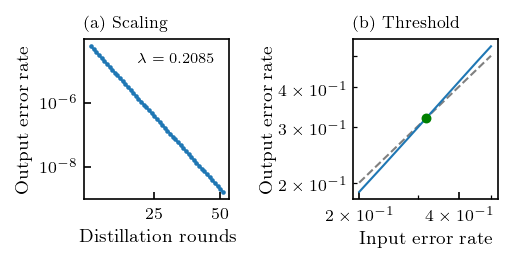

In [5]:
column_width = 3.4

fig, axes = plt.subplots(
    1, 2,
    figsize=(column_width, 1.75),
    sharex=False,
    sharey=False
)

# ── Plot 1: scaling ──────────────────────────────────────
ax = axes[0]

ax.plot(
    rounds_arr,
    output_error_rate_arr,
    'o-',
    markersize=2.2,
    linewidth=1.0,
    markeredgewidth=0.0,
    zorder=3,
    label='_nolegend_'
)

dummy = plt.Line2D(
    [],
    [],
    linestyle='none',
    label=rf'$\lambda={lambda_:.4f}$'
)

ax.legend(
    handles=[dummy],
    frameon=False,
    loc='upper right',
    handlelength=0,
    handletextpad=0,
    fontsize=7
)

ax.set_yscale("log")
ax.set_xlabel("Distillation rounds")
ax.set_ylabel("Output error rate")
ax.set_title(r"(a) Scaling", loc="left", fontsize=8)

# No top/right ticks
ax.tick_params(which='both', direction='in', top=False, right=False)
ax.set_xticks([25, 50])
ax.set_xticklabels([r'$25$', r'$50$'])
ax.xaxis.set_minor_formatter(mticker.NullFormatter())


# ── Plot 2: threshold ────────────────────────────────────
ax = axes[1]

ax.plot(
    input_error_rate,
    input_error_rate,
    color="gray",
    linestyle="--",
    linewidth=1.0
)

ax.plot(
    input_error_rate,
    output_error_rate,
    linewidth=1.0
)

ax.scatter(
    intersection,
    intersection,
    color="green",
    s=14,
    zorder=5
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Input error rate")
ax.set_ylabel("Output error rate")
ax.set_title(r"(b) Threshold", loc="left", fontsize=8)

# No top/right ticks
ax.tick_params(which='both', direction='in', top=False, right=False)
ax.set_xticks([2e-1, 4e-1])
ax.set_xticklabels([r'$2\times10^{-1}$', r'$4\times10^{-1}$'])
ax.xaxis.set_minor_formatter(mticker.NullFormatter())

# Slightly reduce distance between plot 2's y-label and its axis
ax.yaxis.labelpad = 1


# More horizontal space between the two panels
fig.subplots_adjust(
    left=0.17,
    right=0.98,
    bottom=0.27,
    top=0.88,
    wspace=0.85
)

plt.show()